In [187]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [188]:
import numpy as np
import pandas as pd

In [189]:

full_df_drive = pd.read_pickle("/content/drive/MyDrive/wesad_full_preprocessed.pkl")

In [190]:
full_df = full_df_drive

In [191]:
import numpy as np
from scipy.special import expit
from sklearn.preprocessing import StandardScaler

def compute_autonomic_dysregulation(df, per_subject=True):
    """
    Computes a continuous autonomic dysregulation severity score S ∈ [0, 1].

    Designed to generalize beyond WESAD to any multimodal physiological dataset
    containing HRV, EDA, and peripheral temperature signals.

    Parameters
    ----------
    df : pd.DataFrame
        Must contain subject-normalized features (z-scores per subject).
    per_subject : bool
        If True, normalizes features per subject before computing D.
        Set False if already normalized.

    Signal coverage:
        HRV  → HRV_SDNN, HRV_RMSSD, HRV_MeanNN (chest ECG)
                HRV_SDNN_bvp, HRV_RMSSD_bvp, HRV_MeanNN_bvp (wrist BVP)
        EDA  → scl_mean (tonic), scr_peak_freq (phasic)
        TEMP → temp_mean
    """
    df = df.copy()

    # ── Step 1: Per-subject normalization if not already done ────────
    if per_subject:
        hrv_features = [
            'HRV_SDNN', 'HRV_RMSSD', 'HRV_MeanNN',
            'HRV_SDNN_bvp', 'HRV_RMSSD_bvp', 'HRV_MeanNN_bvp',
            'scl_mean', 'scr_peak_freq', 'temp_mean'
        ]
        for subj in df['subject'].unique():
            mask = df['subject'] == subj
            scaler = StandardScaler()
            df.loc[mask, hrv_features] = scaler.fit_transform(
                df.loc[mask, hrv_features]
            )

    z = df  # shorthand

    # ── Step 2: HRV composite (chest + wrist averaged) ───────────────
    # Averaging chest and wrist reduces device-specific noise
    # Both measure the same underlying construct — vagal tone
    HRV_SDNN_avg  = (z['HRV_SDNN']   + z['HRV_SDNN_bvp'])  / 2
    HRV_RMSSD_avg = (z['HRV_RMSSD']  + z['HRV_RMSSD_bvp']) / 2
    HRV_MeanNN_avg= (z['HRV_MeanNN'] + z['HRV_MeanNN_bvp'])/ 2

    # ── Step 3: HRV dysregulation index ─────────────────────────────
    # RMSSD > SDNN > MeanNN in weight:
    # RMSSD is the most sensitive to acute stress (parasympathetic withdrawal)
    # SDNN reflects overall HRV — slightly less acute but more stable
    # MeanNN inversely tracks HR — included but lowest HRV weight
    # All three are negated: lower HRV = higher dysregulation
    HRV_component = (
        - 0.45 * HRV_RMSSD_avg   # most sensitive to acute stress
        - 0.35 * HRV_SDNN_avg    # overall autonomic variability
        - 0.20 * HRV_MeanNN_avg  # inverse HR proxy
    )
    # HRV_component ∈ approximately [-2, 2] after normalization

    # ── Step 4: EDA dysregulation index ─────────────────────────────
    # SCL (tonic) reflects sustained sympathetic arousal — most stable EDA feature
    # SCR peak frequency reflects phasic bursts — noisy but directionally valid
    # SCL weighted 3x more than SCR due to stability advantage
    EDA_component = (
        + 0.75 * z['scl_mean']       # tonic sympathetic arousal
        + 0.25 * z['scr_peak_freq']  # phasic bursts — downweighted
    )

    # ── Step 5: Temperature dysregulation index ──────────────────────
    # Peripheral vasoconstriction under stress → lower wrist temp
    # Effect is slow (minutes) and subtle — lowest weight in D
    # Negated: lower temp = higher dysregulation
    TEMP_component = (
        - 1.0 * z['temp_mean']
    )

    # ── Step 6: Weighted composite dysregulation score D ────────────
    # Weights reflect established clinical evidence hierarchy:
    #   HRV: 0.60 — gold standard autonomic marker, dual-device averaged
    #   EDA: 0.30 — strong sympathetic marker, well-validated for stress
    #   TEMP: 0.10 — secondary, slow-moving, context-dependent
    D = (
        0.60 * HRV_component +
        0.30 * EDA_component +
        0.10 * TEMP_component
    )

    # ── Step 7: Sigmoid normalization → σ(D) ∈ [0, 1] ───────────────
    # Scale factor 2.0 controls sigmoid steepness
    # Higher = more binary behavior, lower = more gradual
    sigma_D = expit(2.0 * D)

    # ── Step 8: Label-based prior S_L ───────────────────────────────
    SEVERITY_MAP = {
        0: None,   # undefined — will be dropped
        1: 0.00,   # baseline    — resting state, no dysregulation
        2: 0.80,   # stress      — TSST-induced, high sympathetic activation
        3: 0.15,   # amusement   — mild positive arousal, low clinical relevance
                   #               reduced from 0.2: positive valence suppresses
                   #               clinical dysregulation interpretation
        4: 0.05,   # meditation  — active relaxation, slightly below baseline
                   #               due to parasympathetic enhancement
    }
    df['S_L']    = df['label'].map(SEVERITY_MAP)
    df           = df[df['S_L'].notna()].reset_index(drop=True)
    sigma_D      = sigma_D[df.index] if hasattr(sigma_D, 'iloc') else sigma_D[:len(df)]

    df['D']       = D.values[:len(df)] if hasattr(D, 'values') else D[:len(df)]
    df['sigma_D'] = sigma_D

    # ── Step 9: Final severity — label prior + physiological evidence
    # 0.65/0.35 split:
    # Label prior dominates because WESAD is a controlled experiment
    # with verified ground truth conditions.
    # For real-world ambulatory data, shift toward 0.4/0.6 (less label trust)
    df['S'] = 0.65 * df['S_L'] + 0.35 * df['sigma_D']

    return df


# ── Apply ─────────────────────────────────────────────────────────
full_df_severity = compute_autonomic_dysregulation(full_df, per_subject=True)

# ── Validate ──────────────────────────────────────────────────────
label_map = {1:'Baseline', 2:'Stress', 3:'Amusement', 4:'Meditation'}
full_df_severity['label_name'] = full_df_severity['label'].map(label_map)

print("=== Mean Severity S by Condition ===")
print(full_df_severity.groupby('label_name')['S'].agg(['mean','std','min','max']))

print("\n=== Physiological D by Condition ===")
print(full_df_severity.groupby('label_name')['D'].agg(['mean','std']))

print("\n=== sigma_D by Condition ===")
print(full_df_severity.groupby('label_name')['sigma_D'].agg(['mean','std']))

=== Mean Severity S by Condition ===
                mean       std       min       max
label_name                                        
Amusement   0.261868  0.070154  0.111136  0.423815
Baseline    0.146053  0.050653  0.023335  0.270316
Meditation  0.199873  0.052709  0.055447  0.315836
Stress      0.748430  0.063738  0.572792  0.842178

=== Physiological D by Condition ===
                mean       std
label_name                    
Amusement  -0.078266  0.527761
Baseline   -0.184170  0.325237
Meditation -0.053456  0.345870
Stress      0.355103  0.431611

=== sigma_D by Condition ===
                mean       std
label_name                    
Amusement   0.469622  0.200440
Baseline    0.417295  0.144722
Meditation  0.478208  0.150596
Stress      0.652656  0.182107


In [192]:
full_df_severity

,bpm,HRV_MeanNN,HRV_SDNN,HRV_RMSSD,label,scr_peak_freq,scr_amp_mean,scl_mean,scl_slope,lf_power,...,HRV_SDNN_bvp,HRV_RMSSD_bvp,temp_mean,temp_std,subject,S_L,D,sigma_D,S,label_name
0,71.600077,-0.125604,-0.270823,-0.319535,1,0.234729,0.003176,1.567353,-5.555445e-06,8.728580e-07,...,0.259097,0.353171,1.361839,0.054123,S2,0.00,0.247994,0.621516,0.217531,Baseline
1,71.620713,-0.130107,-1.335127,-0.726577,1,1.289729,0.002594,1.210047,-4.674417e-06,2.750015e-07,...,-0.419607,-0.359270,1.323643,0.032573,S2,0.00,0.610765,0.772333,0.270316,Baseline
2,72.004891,-0.213473,-0.931876,-0.249337,1,1.384207,0.002551,0.923484,-3.522025e-06,5.179775e-07,...,-0.565256,-0.527375,1.384084,0.057163,S2,0.00,0.491789,0.727818,0.254736,Baseline
3,72.173560,-0.249794,-0.876773,-0.310954,1,0.203237,0.003149,0.708613,-2.591458e-06,4.824999e-07,...,-0.518153,-0.493699,1.440832,0.017377,S2,0.00,0.336244,0.662060,0.231721,Baseline
4,72.042895,-0.221672,-0.989890,-0.313285,1,-0.190420,0.003630,0.540582,-2.159915e-06,2.903708e-07,...,-0.396342,-0.443821,1.437558,0.020178,S2,0.00,0.297750,0.644626,0.225619,Baseline
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
680,59.997119,1.105978,1.048221,1.284868,4,-0.080878,0.005707,1.014823,-2.660445e-07,2.895767e-05,...,0.024292,0.012131,-0.962026,0.024010,S17,0.05,-0.067538,0.466282,0.195699,Meditation
681,59.304852,1.172253,1.416487,1.621901,4,0.485270,0.005034,0.999732,-2.106074e-07,2.898417e-05,...,-0.026242,-0.054847,-0.976360,0.030594,S17,0.05,-0.099137,0.450593,0.190208,Meditation
682,58.328445,1.268404,1.346426,1.934371,4,0.808784,0.004389,0.962408,-1.154113e-06,2.106408e-05,...,-0.158485,-0.300059,-0.903371,0.036606,S17,0.05,-0.086469,0.456873,0.192405,Meditation
683,58.710379,1.230412,0.848722,1.915802,4,0.458311,0.004083,0.896522,-1.024168e-06,2.648288e-05,...,-0.315796,-0.338973,-0.905306,0.032242,S17,0.05,-0.055386,0.472336,0.197817,Meditation


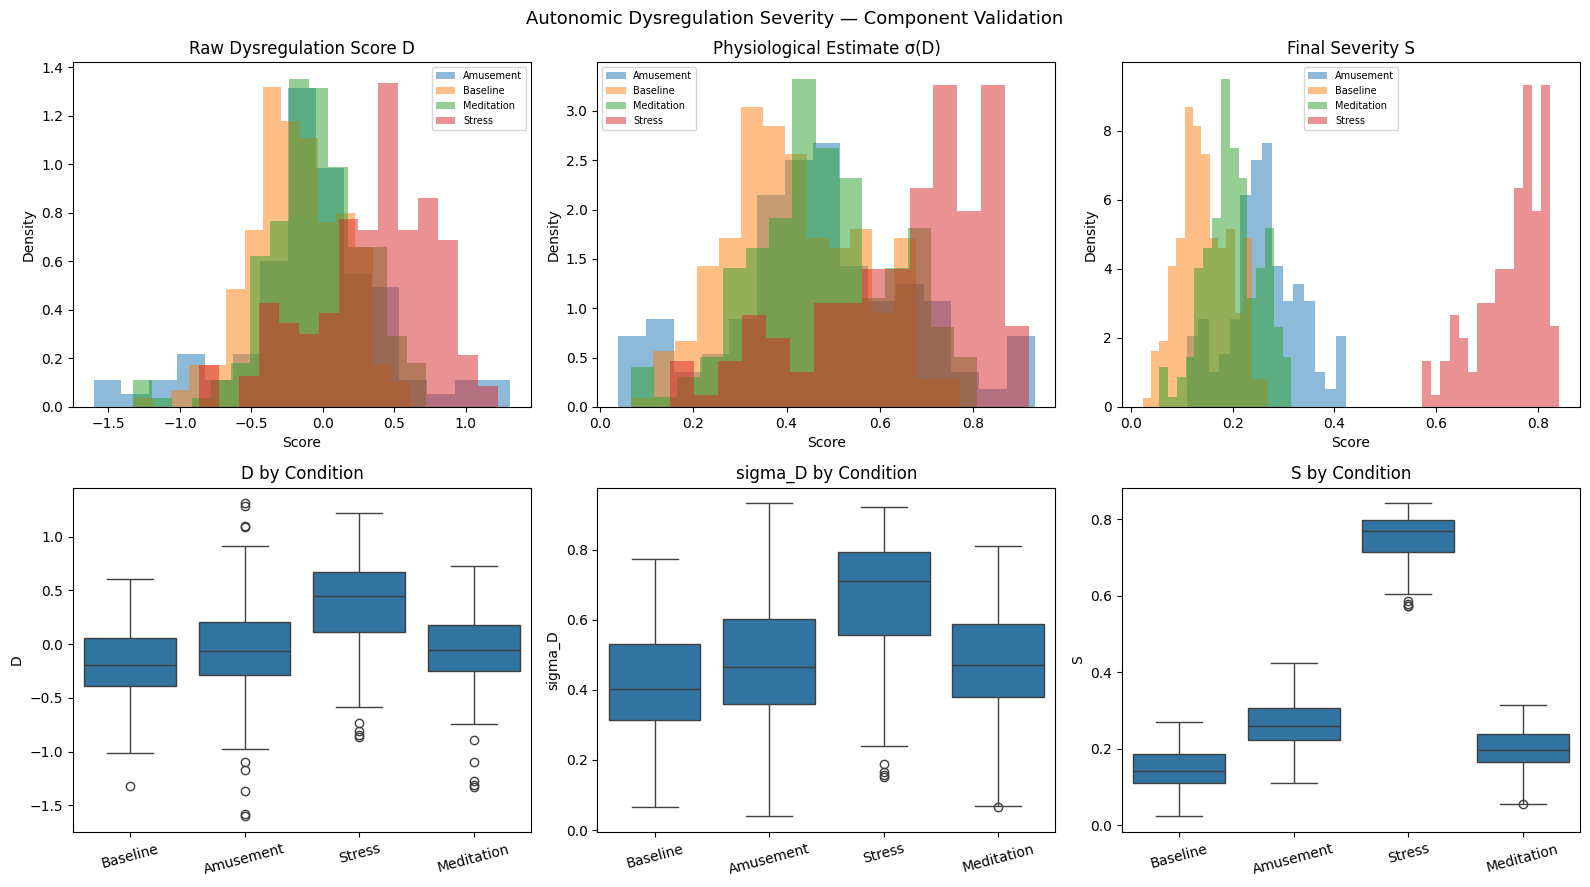


Correlation between σ(D) and S_L: 0.472
Target: 0.4–0.7 (too low = D is noise, too high = redundant with label)


In [193]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 3, figsize=(16, 9))

# Row 1: Distribution of each component by condition
for ax, (col, title) in zip(axes[0], [
    ('D',       'Raw Dysregulation Score D'),
    ('sigma_D', 'Physiological Estimate σ(D)'),
    ('S',       'Final Severity S')
]):
    for name, grp in full_df_severity.groupby('label_name'):
        ax.hist(grp[col], bins=15, alpha=0.5, label=name, density=True)
    ax.set_title(title)
    ax.set_xlabel('Score')
    ax.set_ylabel('Density')
    ax.legend(fontsize=7)

# Row 2: Box plots for cleaner comparison
for ax, col in zip(axes[1], ['D', 'sigma_D', 'S']):
    sns.boxplot(data=full_df_severity, x='label_name', y=col, ax=ax,
                order=['Baseline','Amusement','Stress','Meditation'])
    ax.set_title(f'{col} by Condition')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=15)

plt.suptitle('Autonomic Dysregulation Severity — Component Validation', fontsize=13)
plt.tight_layout()
plt.show()

# Correlation between sigma_D and S_L — should be positive and moderate
corr = full_df_severity['sigma_D'].corr(full_df_severity['S_L'])
print(f"\nCorrelation between σ(D) and S_L: {corr:.3f}")
print("Target: 0.4–0.7 (too low = D is noise, too high = redundant with label)")

In [213]:
def normalize_per_subject(df, feature_cols):
    df = df.copy()
    for subj in df['subject'].unique():
        mask = df['subject'] == subj
        scaler = StandardScaler()
        df.loc[mask, feature_cols] = scaler.fit_transform(df.loc[mask, feature_cols])
    return df

FEATURE_COLS = [
    'HRV_SDNN', 'HRV_RMSSD', 'HRV_MeanNN',
    'HRV_SDNN_bvp', 'HRV_RMSSD_bvp', 'HRV_MeanNN_bvp',
    'scl_mean', 'scr_peak_freq', 'temp_mean'
]

full_df_norm = normalize_per_subject(full_df_severity, FEATURE_COLS)

# Splits
TRAIN_SUBJECTS = ['S2','S3','S4','S5','S6','S7','S8','S9','S10','S11']
VAL_SUBJECTS   = ['S13','S14']
TEST_SUBJECTS  = ['S15','S16','S17']

train_df = full_df_norm[full_df_norm['subject'].isin(TRAIN_SUBJECTS)].reset_index(drop=True)
val_df   = full_df_norm[full_df_norm['subject'].isin(VAL_SUBJECTS)].reset_index(drop=True)
test_df  = full_df_norm[full_df_norm['subject'].isin(TEST_SUBJECTS)].reset_index(drop=True)

In [214]:
full_df_severity.head()

,bpm,HRV_MeanNN,HRV_SDNN,HRV_RMSSD,label,scr_peak_freq,scr_amp_mean,scl_mean,scl_slope,lf_power,...,HRV_SDNN_bvp,HRV_RMSSD_bvp,temp_mean,temp_std,subject,S_L,D,sigma_D,S,label_name
0,71.600077,-0.125604,-0.270823,-0.319535,1,0.234729,0.003176,1.567353,-0.000006,8.728580e-07,...,0.259097,0.353171,1.361839,0.054123,S2,0.0,0.247994,0.621516,0.217531,Baseline
1,71.620713,-0.130107,-1.335127,-0.726577,1,1.289729,0.002594,1.210047,-0.000005,2.750015e-07,...,-0.419607,-0.359270,1.323643,0.032573,S2,0.0,0.610765,0.772333,0.270316,Baseline
2,72.004891,-0.213473,-0.931876,-0.249337,1,1.384207,0.002551,0.923484,-0.000004,5.179775e-07,...,-0.565256,-0.527375,1.384084,0.057163,S2,0.0,0.491789,0.727818,0.254736,Baseline
3,72.173560,-0.249794,-0.876773,-0.310954,1,0.203237,0.003149,0.708613,-0.000003,4.824999e-07,...,-0.518153,-0.493699,1.440832,0.017377,S2,0.0,0.336244,0.662060,0.231721,Baseline
4,72.042895,-0.221672,-0.989890,-0.313285,1,-0.190420,0.003630,0.540582,-0.000002,2.903708e-07,...,-0.396342,-0.443821,1.437558,0.020178,S2,0.0,0.297750,0.644626,0.225619,Baseline


In [215]:
full_df_norm.head()

,bpm,HRV_MeanNN,HRV_SDNN,HRV_RMSSD,label,scr_peak_freq,scr_amp_mean,scl_mean,scl_slope,lf_power,...,HRV_SDNN_bvp,HRV_RMSSD_bvp,temp_mean,temp_std,subject,S_L,D,sigma_D,S,label_name
0,71.600077,-0.125604,-0.270823,-0.319535,1,0.234729,0.003176,1.567353,-0.000006,8.728580e-07,...,0.259097,0.353171,1.361839,0.054123,S2,0.0,0.247994,0.621516,0.217531,Baseline
1,71.620713,-0.130107,-1.335127,-0.726577,1,1.289729,0.002594,1.210047,-0.000005,2.750015e-07,...,-0.419607,-0.359270,1.323643,0.032573,S2,0.0,0.610765,0.772333,0.270316,Baseline
2,72.004891,-0.213473,-0.931876,-0.249337,1,1.384207,0.002551,0.923484,-0.000004,5.179775e-07,...,-0.565256,-0.527375,1.384084,0.057163,S2,0.0,0.491789,0.727818,0.254736,Baseline
3,72.173560,-0.249794,-0.876773,-0.310954,1,0.203237,0.003149,0.708613,-0.000003,4.824999e-07,...,-0.518153,-0.493699,1.440832,0.017377,S2,0.0,0.336244,0.662060,0.231721,Baseline
4,72.042895,-0.221672,-0.989890,-0.313285,1,-0.190420,0.003630,0.540582,-0.000002,2.903708e-07,...,-0.396342,-0.443821,1.437558,0.020178,S2,0.0,0.297750,0.644626,0.225619,Baseline


In [216]:
SEQ_LEN = 5

def create_sequences_regression(df, feature_cols, seq_len):
    X_all, y_all = [], []
    for subj in df['subject'].unique():
        sdf = df[df['subject'] == subj].reset_index(drop=True)
        X   = sdf[feature_cols].values.astype(np.float32)
        X = sdf.drop(columns=['D', 'sigma_D', 'S_L','label_name', 'subject', 'label', 'S']).values.astype(np.float32)
        y   = sdf['S'].values.astype(np.float32)  # Changed 'severity' to 'S'
        if len(X) < seq_len:
            continue
        for i in range(len(X) - seq_len + 1):
            X_all.append(X[i:i+seq_len])
            y_all.append(np.mean(y[i:i+seq_len]))  # mean severity over window
    return np.array(X_all), np.array(y_all)

X_train_seq, y_train_seq = create_sequences_regression(train_df, FEATURE_COLS, SEQ_LEN)
X_val_seq,   y_val_seq   = create_sequences_regression(val_df,   FEATURE_COLS, SEQ_LEN)
X_test_seq,  y_test_seq  = create_sequences_regression(test_df,  FEATURE_COLS, SEQ_LEN)

print(f"X_train: {X_train_seq.shape} | y_train: {y_train_seq.shape}")
print(f"y_train unique values: {np.unique(y_train_seq)}")

X_train: (413, 5, 14) | y_train: (413,)
y_train unique values: [0.06413519 0.06475912 0.0743653  0.07871331 0.08560868 0.08958366
 0.08990298 0.09260339 0.09725468 0.10021186 0.10114733 0.10132264
 0.10142859 0.10188486 0.10299554 0.10339876 0.10435315 0.10504194
 0.10509207 0.10682333 0.11066135 0.11305883 0.11444137 0.11456766
 0.11473496 0.11478579 0.11549874 0.11713637 0.11864158 0.11923592
 0.119437   0.11948185 0.12122921 0.1216403  0.12255335 0.12273858
 0.1234076  0.12722543 0.12754919 0.12782276 0.12865575 0.12870705
 0.13042209 0.13100186 0.13175829 0.13201894 0.1320221  0.13205072
 0.13281326 0.13305242 0.13386728 0.13449498 0.13497612 0.13603103
 0.13620797 0.13673247 0.13687018 0.13705966 0.13756138 0.13786165
 0.1384908  0.13923833 0.13972263 0.14092445 0.14119534 0.14290962
 0.14317062 0.14394036 0.14423172 0.14720902 0.14728011 0.14746448
 0.15069963 0.15279856 0.15352824 0.15445018 0.15536544 0.1562039
 0.15634689 0.1569299  0.15711245 0.15771191 0.15830174 0.1609518
 

In [217]:
X_train_seq.shape

(413, 5, 14)

In [218]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [219]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def make_loader_reg(X, y, batch_size=32, shuffle=True):
    ds = TensorDataset(
        torch.tensor(X, dtype=torch.float32),
        torch.tensor(y, dtype=torch.float32)  # float32, not long
    )
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)

train_loader = make_loader_reg(X_train_seq, y_train_seq, shuffle=True)
val_loader   = make_loader_reg(X_val_seq,   y_val_seq,   shuffle=False)
test_loader  = make_loader_reg(X_test_seq,  y_test_seq,  shuffle=False)

In [220]:
X_train_seq.shape

(413, 5, 14)

In [229]:
class BiLSTMRegression(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, dropout=0.3):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers,
                            batch_first=True, bidirectional=True,
                            dropout=dropout if num_layers > 1 else 0)
        # self.attention = Attention(hidden_size)  # same Attention class as before
        self.bn        = nn.BatchNorm1d(hidden_size * 2)
        self.fc        = nn.Sequential(
            nn.Linear(hidden_size * 2, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, 1),      # single output neuron
            # nn.Linear(32,1)        # clamps output to 0-1 range
        )

    def forward(self, x):
        out, _  = self.lstm(x)
        # context = self.attention(out)
        out = out[:, -1, :]
        context = self.bn(out)
        return self.fc(context).squeeze(1)  # shape: (batch,)

HIDDEN_SIZE = 64
NUM_LAYERS  = 3
DROPOUT     = 0.3
LR          = 0.001
NUM_EPOCHS  = 80
INPUT_SIZE = 14
PATIENCE    = 15

model     = BiLSTMRegression(INPUT_SIZE, HIDDEN_SIZE, NUM_LAYERS, DROPOUT).to(device)
criterion = nn.MSELoss()          # regression loss
optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

In [230]:
train_losses, val_losses = [], []
best_val_loss    = float('inf')
best_model_state = None
patience_counter = 0

for epoch in range(NUM_EPOCHS):
    model.train()
    epoch_loss = 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        preds = model(X_batch)
        loss  = criterion(preds, y_batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        epoch_loss += loss.item()

    avg_train = epoch_loss / len(train_loader)
    train_losses.append(avg_train)

    model.eval()
    val_loss = 0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            val_loss += criterion(model(X_batch), y_batch).item()

    avg_val = val_loss / len(val_loader)
    val_losses.append(avg_val)
    scheduler.step()

    print(f"Epoch {epoch+1:02d} | Train MSE: {avg_train:.4f} | Val MSE: {avg_val:.4f}")

    if avg_val < best_val_loss:
        best_val_loss    = avg_val
        best_model_state = {k: v.clone() for k, v in model.state_dict().items()}
        patience_counter = 0
        print(f"  ✓ New best val loss: {best_val_loss:.3f}")
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"Early stopping at epoch {epoch+1}")
            break

model.load_state_dict(best_model_state)
print(f"\nBest val loss: {best_val_loss:.4f}")

Epoch 01 | Train MSE: 0.1378 | Val MSE: 0.1912
  ✓ New best val loss: 0.191
Epoch 02 | Train MSE: 0.0666 | Val MSE: 0.1797
  ✓ New best val loss: 0.180
Epoch 03 | Train MSE: 0.0483 | Val MSE: 0.1608
  ✓ New best val loss: 0.161
Epoch 04 | Train MSE: 0.0407 | Val MSE: 0.1197
  ✓ New best val loss: 0.120
Epoch 05 | Train MSE: 0.0320 | Val MSE: 0.1120
  ✓ New best val loss: 0.112
Epoch 06 | Train MSE: 0.0376 | Val MSE: 0.0774
  ✓ New best val loss: 0.077
Epoch 07 | Train MSE: 0.0348 | Val MSE: 0.0518
  ✓ New best val loss: 0.052
Epoch 08 | Train MSE: 0.0311 | Val MSE: 0.0432
  ✓ New best val loss: 0.043
Epoch 09 | Train MSE: 0.0283 | Val MSE: 0.0398
  ✓ New best val loss: 0.040
Epoch 10 | Train MSE: 0.0301 | Val MSE: 0.0336
  ✓ New best val loss: 0.034
Epoch 11 | Train MSE: 0.0276 | Val MSE: 0.0318
  ✓ New best val loss: 0.032
Epoch 12 | Train MSE: 0.0249 | Val MSE: 0.0325
Epoch 13 | Train MSE: 0.0263 | Val MSE: 0.0651
Epoch 14 | Train MSE: 0.0241 | Val MSE: 0.0339
Epoch 15 | Train MSE: 0

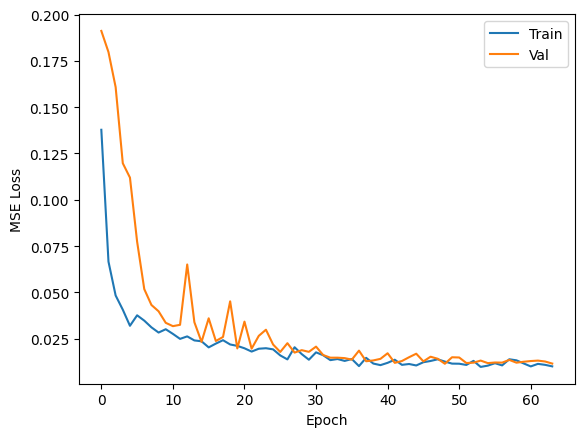

In [231]:
plt.plot(train_losses, label='Train')
plt.plot(val_losses,   label='Val')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.show()

MSE:  0.0135
RMSE: 0.1163
MAE:  0.0831


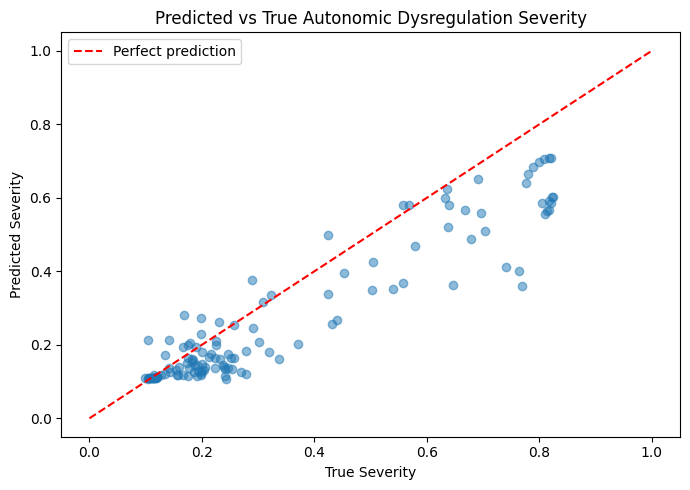

In [232]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

model.eval()
all_preds, all_targets = [], []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        preds = model(X_batch.to(device)).cpu().numpy()
        all_preds.extend(preds)
        all_targets.extend(y_batch.numpy())

all_preds   = np.array(all_preds)
all_targets = np.array(all_targets)

mse  = mean_squared_error(all_targets, all_preds)
mae  = mean_absolute_error(all_targets, all_preds)
rmse = np.sqrt(mse)

print(f"MSE:  {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE:  {mae:.4f}")

# Scatter plot: predicted vs actual severity
plt.figure(figsize=(7, 5))
plt.scatter(all_targets, all_preds, alpha=0.5)
plt.plot([0, 1], [0, 1], 'r--', label='Perfect prediction')
plt.xlabel('True Severity')
plt.ylabel('Predicted Severity')
plt.title('Predicted vs True Autonomic Dysregulation Severity')
plt.legend()
plt.tight_layout()
plt.show()

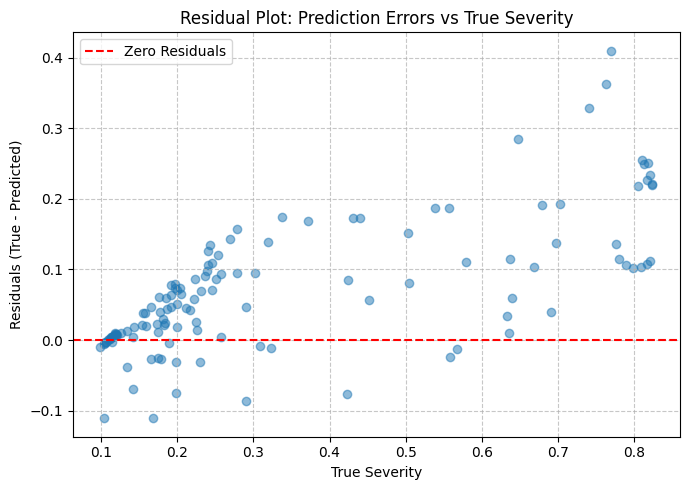

In [233]:
# Residual Plot
residuals = all_targets - all_preds

plt.figure(figsize=(7, 5))
plt.scatter(all_targets, residuals, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--', label='Zero Residuals')
plt.xlabel('True Severity')
plt.ylabel('Residuals (True - Predicted)')
plt.title('Residual Plot: Prediction Errors vs True Severity')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

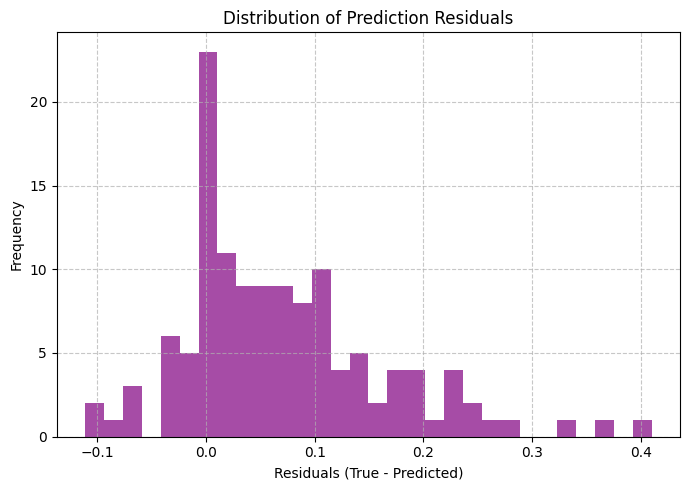

In [234]:
# Distribution of Residuals
plt.figure(figsize=(7, 5))
plt.hist(residuals, bins=30, alpha=0.7, color='purple')
plt.xlabel('Residuals (True - Predicted)')
plt.ylabel('Frequency')
plt.title('Distribution of Prediction Residuals')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

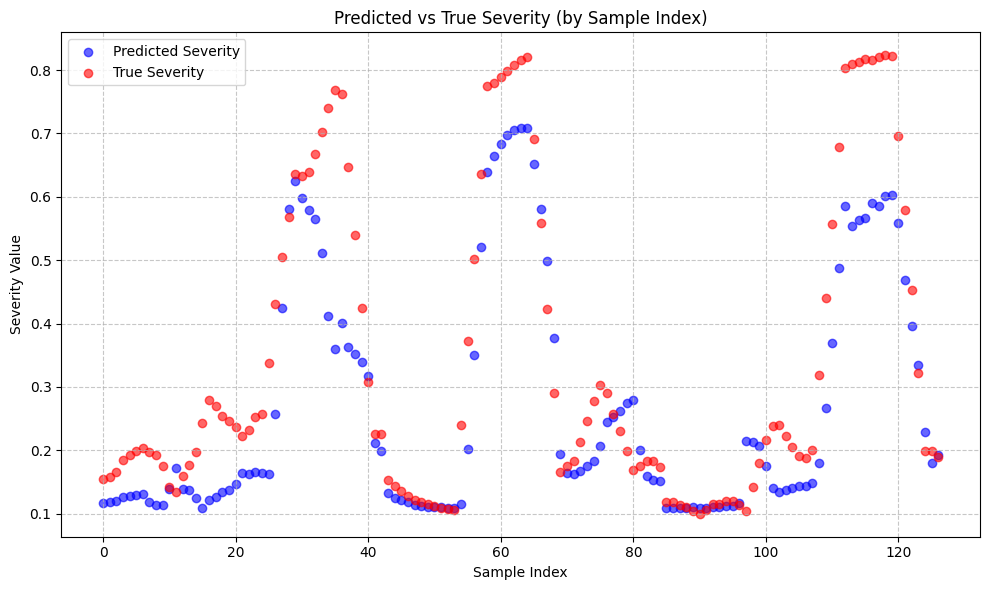

In [235]:
plt.figure(figsize=(10, 6))
plt.scatter(range(len(all_preds)), all_preds, alpha=0.6, label='Predicted Severity', color='blue')
plt.scatter(range(len(all_targets)), all_targets, alpha=0.6, label='True Severity', color='red')
plt.xlabel('Sample Index')
plt.ylabel('Severity Value')
plt.title('Predicted vs True Severity (by Sample Index)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [238]:
full_df_severity.groupby('label_name')['S'].agg(['mean','std'])

,mean,std
label_name,,
Amusement,0.261868,0.070154
Baseline,0.146053,0.050653
Meditation,0.199873,0.052709
Stress,0.748430,0.063738


In [240]:
from google.colab import drive
drive.mount('/content/drive')
save_path = "/content/drive/MyDrive/Final_Physiological_pipeline_with_dynamic_dysfunctional_labelling.pth"

checkpoint = {
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'epoch': epoch,
    'loss': loss
}

torch.save(checkpoint, save_path)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [241]:
torch.save(model.state_dict(), save_path)
print("Model saved successfully!")

Model saved successfully!


In [ ]:
# to load model for inference
# model.load_state_dict(torch.load(save_path))
# model.eval()